TOI-1338 b Analysis

In [4]:
import numpy as np
import math as math
import matplotlib.pyplot as plt
from lmfit import Model
from scipy.optimize import curve_fit
from scipy.signal import medfilt
import pandas as pd

In [5]:
def sa(t, c,a1,a2,a3,a4,P,t1,t2,t3,t4):
    return c+a1*np.sin(2*math.pi*(t-t1)/P)+a2*np.sin(2*math.pi*(t-t2)/(P/2))+a3*np.sin(2*math.pi*(t-t3)/(P/3))+a4*np.sin(2*math.pi*(t-t4)/(P/4))

In [6]:
# cleaning the data - need to subtract column 3 by column 2
# normalizing the flux

df = pd.read_csv('ForCurveFitting.txt', sep=',')

new_sap_values = []

for idx, row in df.iterrows():
    sap_flux = row.iloc[1]
    sap_bkg = row.iloc[2]
    new_sap_value = sap_flux - sap_bkg
    new_sap_values.append(new_sap_value)

df[3] = new_sap_values
df = df.drop(df.columns[[1, 2]], axis=1)

df.to_csv('new_for_curve_fitting.txt', sep=',', index=False, header=False)

In [7]:

lc=np.loadtxt("/Users/troyl/OneDrive/Documents/code_dev/NASA_internship/project_one/homework_one/new_for_curve_fitting.txt", delimiter=',')
print(lc.shape)
print(lc[:,0])

(993, 2)
[1325.65620364 1325.6770371  1325.718704   1325.76037091 1325.78120437
 1325.8645382  1325.88537166 1326.01037244 1326.07287283 1326.0937063
 1326.11453977 1326.1562067  1326.17704017 1326.19787364 1326.21870711
 1326.23954057 1326.26037404 1326.28120751 1326.30204098 1326.32287445
 1326.3645414  1326.38537487 1326.40620834 1326.42704181 1326.44787528
 1326.48954223 1326.5103757  1326.53120917 1326.55204265 1326.57287612
 1326.59370959 1326.61454307 1326.65621002 1326.69787696 1326.71871044
 1326.73954391 1326.76037739 1326.78121086 1326.80204434 1326.88537824
 1326.92704519 1326.94787867 1327.0103791  1327.03121258 1327.05204605
 1327.07287953 1327.09371301 1327.11454648 1327.21871387 1327.23954735
 1327.26038082 1327.2812143  1327.30204778 1327.32288126 1327.34371473
 1327.36454821 1327.38538169 1327.40621517 1327.42704865 1327.44788212
 1327.48954908 1327.51038256 1327.53121603 1327.55204951 1327.57288299
 1327.59371647 1327.61454995 1327.6562169  1327.67705038 1327.6978838

In [8]:
init_vals = [1.00675686,0.0181566137,0.0115096449,0.0229175483,0.242512102,4.86157236,1337.56897,1338.068734,1769.48725,1606.60839]
best_vals, covar = curve_fit(sa, lc[:,0], lc[:,1], p0=init_vals)
print(best_vals)

[ 9.90152896e-01  3.61757851e-03  7.09997906e-04 -1.78380106e-03
 -1.57233033e-03  4.87577944e+00  1.33802361e+03  1.33851831e+03
  1.77357554e+03  1.60714671e+03]


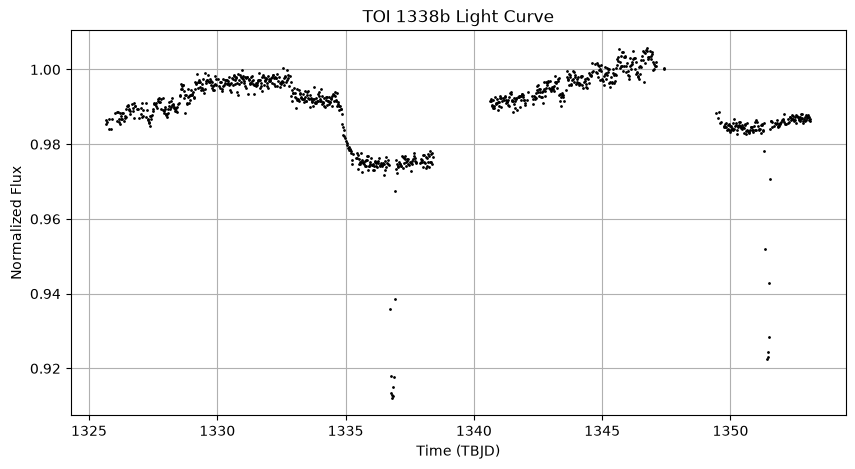

In [13]:
plt.figure(figsize=(10,5))
time = lc[:, 0]
flux = lc[:, 1]
plt.plot(time, flux, marker='.', linestyle='none', color='black', markersize=2)
plt.xlabel('Time (TBJD)')
plt.ylabel('Normalized Flux')
plt.title('TOI 1338b Light Curve')
plt.grid()
plt.show()

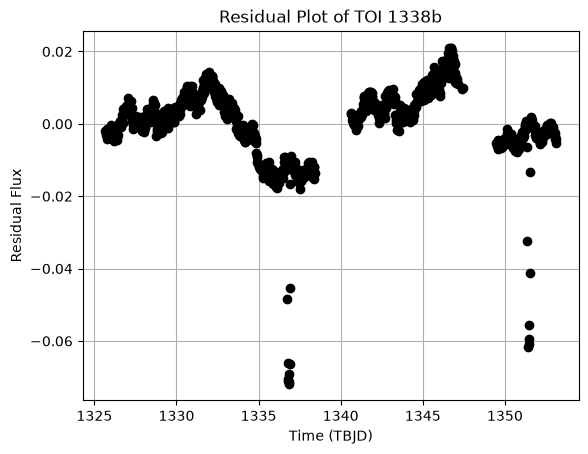

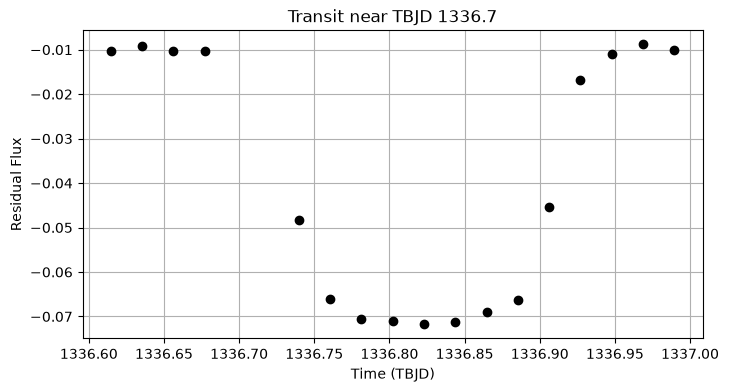

In [15]:
gmodel = Model(sa)
result = gmodel.fit(lc[:,1], t=lc[:,0], c=1.00675686e+00,a1=1.81566125e-02,a2=1.15096449e-02,a3=-3.90924741e-01,a4=-3.89635008e-01,P=4.86157211e+00,t1=1.33756897e+03,t2=1.33806734e+03,t3=1.76948608e+03,t4=1.60662441e+03)
resid=lc.copy()
resid[:,1]=lc[:,1]-result.best_fit
plt.plot(lc[:,0], resid[:,1], 'ko')
plt.grid()
plt.xlabel('Time (TBJD)')
plt.ylabel('Residual Flux')
plt.title("Residual Plot of TOI 1338b")
#plt.plot(lc[:,0], result.best_fit, 'r-')


mask = (resid[:,0] > 1336.6) & (resid[:,0] < 1337.0)
plt.figure(figsize=(8,4))
plt.plot(resid[mask,0], resid[mask,1], 'ko')
plt.xlabel('Time (TBJD)')
plt.ylabel('Residual Flux')
plt.title('Transit near TBJD 1336.7')
plt.grid()

plt.show()
np.savetxt('4Presiduals.txt',resid)



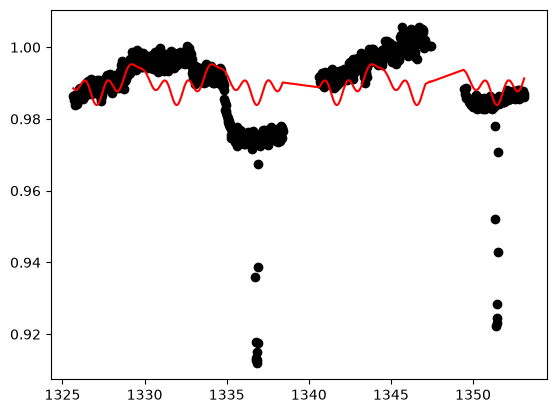

In [11]:
plt.plot(lc[:,0], lc[:,1], 'ko')
plt.plot(lc[:,0], result.best_fit, 'r-')
plt.show()


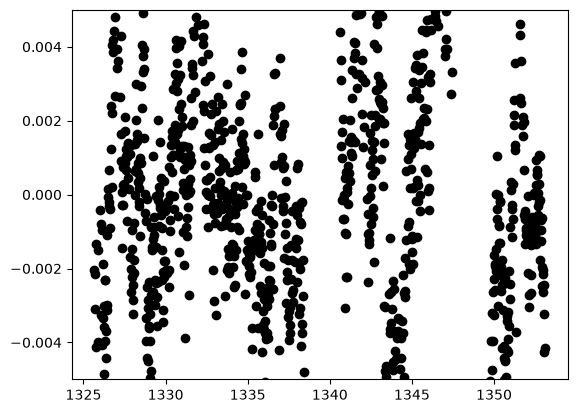

In [12]:
resid2=resid.copy()
resid2[:,1]=resid2[:,1]-medfilt(resid[:,1],201)
plt.plot(lc[:,0],resid2[:,1], 'ko')
plt.ylim(-0.005,0.005)
#plt.plot(lc[:,0], result.best_fit, 'r-')
plt.show()
np.savetxt('4P_med201_residuals.txt',resid2)